# US-JEPA Denoising: Model A (Mamba) vs Model B (Physics-Informed) vs Model C (U-Net) vs Model D (Restormer)

One merged, Kaggle-ready notebook. All four decoders sit on top of the **same frozen/fine-tuned pretrained US-JEPA encoder**
(architecture and loading code taken verbatim from `02_USJEPA_Advanced_Denoising`).

- **Model A** :US-JEPA Encoder + Visual-Mamba-style decoder (selective scan)
- **Model B** : US-JEPA Encoder + Physics-Informed decoder (speckle gating + physics loss)
- **Model C** : US-JEPA Encoder + U-Net-style decoder (residual conv up-blocks)
- **Model D** : US-JEPA Encoder + Restormer-style decoder (MDTA channel attention + GDFN)

## 0. Kaggle data sources

## 1. Install dependencies

In [1]:
!pip install -q torch torchvision einops matplotlib tqdm pillow opencv-python-headless
!pip install -q tensorboard
!pip install -q lpips pytorch-msssim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.1 MB/s eta 0:00:00


## 2. Imports & Reproducibility

In [2]:
import os
import glob
import json
import time
import math
import random
import hashlib
import copy
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from einops import rearrange
import lpips
from pytorch_msssim import ssim as ssim_metric

try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD = True
except ImportError:
    TENSORBOARD = False
    print('TensorBoard not available — skipping TB logging.')

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


## 3. Locate the pretrained encoder checkpoint

In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input/datasets/onsgui'):
    for f in files:
        print(os.path.join(root, f))
        

/kaggle/input/datasets/onsgui/checkpoints/checkpoints/loss_curves (3).png
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/config.json
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/encoder_best (2).pth
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/predictor_final.pth
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/best_model.pth
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/encoder_best.pth
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/predictor_final (2).pth
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/training_history.json
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/encoder_final.pth
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/masking_vis (5).png
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/eval/knn_pretrained_query44.png
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/eval/similarity_comparison.png
/kaggle/input/datasets/onsgui/checkpoints/checkpoints/eval/embedding_quality_report.json
/kaggle/inp

In [4]:

CHECKPOINT_DIR = "/kaggle/input/datasets/onsgui/checkpoints/checkpoints/"
candidate_names = ['encoder_best.pth', 'pretrained_encoder.pth', 'checkpoint_best.pth', 'checkpoint_last.pth']
found_path = None
for name in candidate_names:
    p = os.path.join(CHECKPOINT_DIR, name)
    if os.path.exists(p):
        found_path = p
        break

if found_path is None:
    raise FileNotFoundError(
        f'No pretrained encoder checkpoint found in {CHECKPOINT_DIR!r}.\n'
        f'Looked for: {candidate_names}\n'
        'Update CHECKPOINT_DIR / candidate_names to match your Kaggle dataset layout.'
    )

PRETRAINED_ENCODER_PATH = found_path
print(f'✓ Found pretrained encoder checkpoint: {PRETRAINED_ENCODER_PATH}')
print(f'  Size: {os.path.getsize(PRETRAINED_ENCODER_PATH) / 1e6:.1f} MB')

✓ Found pretrained encoder checkpoint: /kaggle/input/datasets/onsgui/checkpoints/checkpoints/encoder_best.pth
  Size: 57.6 MB


## 4. Configuration

`CFG_BASE` holds everything shared by all four models (paths, image size, encoder hparams, training schedule, noise params).
Each model then gets its own derived config with **its original loss weights and decoder hparams, unchanged**:

- `CFG_A_SMALL` — Model A (Visual Mamba), pure `w_l1=1.0` loss, `mamba_depth=2`, `mamba_expand=1` (from `02`)
- `CFG_B` — Model B (Physics-Informed), full physics-loss stack (from `02`)
- `CFG_C` — Model C (U-Net), `w_l1=1.0`, `w_ssim=0.5` (from `01`'s `loss_alpha_l1`/`loss_beta_ssim`), `unet_channels=(256,128,64,32)`
- `CFG_D` — Model D (Restormer), same loss weights as `01`, `restormer_heads=8`, `restormer_ffn_expansion=2.66`


In [5]:
CFG_BASE = {
    # Paths
    'data_dir': '/kaggle/input/private-dataset/IMAGES',
    'checkpoint_dir'         : './checkpoints_denoise',
    'log_dir'                : './runs/usjepa_denoise',
    'pretrained_encoder_path': PRETRAINED_ENCODER_PATH,

    # Image
    'img_size'               : 256,
    'img_channels'           : 1,   # grayscale ultrasound

    # ViT encoder — MUST MATCH PRETRAINING EXACTLY
    'patch_size'             : 16,
    'embed_dim'              : 384,   # ViT-Small
    'encoder_depth'          : 8,
    'encoder_heads'          : 6,

    # Encoder fine-tuning switch — the single knob that controls all four models
    'freeze_encoder'         : True,   # True = frozen feature extractor, False = fine-tune end-to-end

    # Synthetic noise
    'noise_types'            : ['speckle', 'gaussian', 'mixed'],   # sampled per-item
    'speckle_var'            : (0.05, 0.25),
    'gaussian_std'           : (0.01, 0.08),   # in [0,1] pixel scale

    # Training
    'batch_size'             : 24,
    'lr'                     : 2e-4,
    'weight_decay'           : 1e-4,
    'epochs'                 : 50,
    'num_workers'            : 0,
    'val_fraction'           : 0.15,
    'mixed_precision'        : True,
    'early_stop_patience'    : 25,
    'grad_clip_norm'         : 1.0,

    # Visual-Mamba decoder (Model A)
    'mamba_depth'            : 4,
    'mamba_state_dim'        : 16,
    'mamba_expand'           : 2,

    # U-Net decoder (Model C) — unchanged from 01
    'unet_channels'          : (256, 128, 64, 32),

    # Restormer decoder (Model D) — unchanged from 01
    'restormer_heads'            : 8,
    'restormer_ffn_expansion'    : 2.66,

    # Decoder regularization — applied to every model's decoder, so it belongs in
    # CFG_BASE, not only in one derived config, or comparisons would be confounded.
    'decoder_dropout'        : 0.0,

    # Fixed validation-noise seed base
    'val_noise_seed_base'    : 12345,

    # Misc
    'seed'                   : SEED,
    'device'                 : str(DEVICE),
}

# Model A: Visual Mamba — pure reconstruction loss, isolates decoder architecture ──
CFG_A = copy.deepcopy(CFG_BASE)
CFG_A.update({
    'w_l1'          : 1.0,
    'w_ssim'        : 0.0,
    'w_edge'        : 0.0,
    'w_speckle_reg' : 0.0,
    'w_smooth'      : 0.0,
    'w_mse'         : 0.0,
})

CFG_A_SMALL = copy.deepcopy(CFG_A)
CFG_A_SMALL.update({
    'mamba_depth': 2,
    'mamba_expand': 1,
})

# ── Model B: Physics-Informed — full physics-loss stack (unchanged from 02) ──
CFG_B = copy.deepcopy(CFG_BASE)
CFG_B.update({
    'w_l1'          : 1.0,
    'w_ssim'        : 0.5,
    'w_edge'        : 0.3,
    'w_speckle_reg' : 0.1,
    'w_smooth'      : 0.05,
    'w_mse'         : 0.0,
})

# ── Model C: U-Net — loss weights unchanged from 01 (alpha_l1=1.0, beta_ssim=0.5, gamma_mse=0.0) ──
CFG_C = copy.deepcopy(CFG_BASE)
CFG_C.update({
    'w_l1'          : 1.0,
    'w_ssim'        : 0.5,
    'w_edge'        : 0.15,
    'w_speckle_reg' : 0.0,
    'w_smooth'      : 0.0,
    'w_mse'         : 0.0,
    'decoder_dropout' : 0.0,  
})

# ── Model D: Restormer — same loss weights as 01's shared config ──
CFG_D = copy.deepcopy(CFG_BASE)
CFG_D.update({
   # 'lr'              : 1.2e-4,  # was 2e-4, inherited from CFG_BASE — Restormer's MDTA attention is the unstable part
    'grad_clip_norm'  : 0.5,
    'w_l1'          : 1.0,
    'w_ssim'        : 0.5,
    'w_edge'        : 0.15,
    'w_speckle_reg' : 0.0,
    'w_smooth'      : 0.0,
    'w_mse'         : 0.0,
    'decoder_dropout' : 0.0,
})

os.makedirs(CFG_BASE['checkpoint_dir'], exist_ok=True)
os.makedirs(CFG_BASE['log_dir'], exist_ok=True)
with open(os.path.join(CFG_BASE['checkpoint_dir'], 'config.json'), 'w') as f:
    json.dump({'CFG_A': CFG_A, 'CFG_A_SMALL': CFG_A_SMALL, 'CFG_B': CFG_B, 'CFG_C': CFG_C, 'CFG_D': CFG_D},
               f, indent=2, default=str)

for name, cfg in [('CFG_A_SMALL', CFG_A_SMALL), ('CFG_B', CFG_B), ('CFG_C', CFG_C), ('CFG_D', CFG_D)]:
    print(name, '| loss weights:', {k: v for k, v in cfg.items() if k.startswith('w_')})

CFG_A_SMALL | loss weights: {'w_l1': 1.0, 'w_ssim': 0.0, 'w_edge': 0.0, 'w_speckle_reg': 0.0, 'w_smooth': 0.0, 'w_mse': 0.0}
CFG_B | loss weights: {'w_l1': 1.0, 'w_ssim': 0.5, 'w_edge': 0.3, 'w_speckle_reg': 0.1, 'w_smooth': 0.05, 'w_mse': 0.0}
CFG_C | loss weights: {'w_l1': 1.0, 'w_ssim': 0.5, 'w_edge': 0.15, 'w_speckle_reg': 0.0, 'w_smooth': 0.0, 'w_mse': 0.0}
CFG_D | loss weights: {'w_l1': 1.0, 'w_ssim': 0.5, 'w_edge': 0.15, 'w_speckle_reg': 0.0, 'w_smooth': 0.0, 'w_mse': 0.0}


In [6]:
print("Checkpoint exists:", os.path.exists(PRETRAINED_ENCODER_PATH))
print("Images folder exists:", os.path.exists(CFG_BASE["data_dir"]))

print("Number of images:",
      len([f for f in os.listdir(CFG_BASE["data_dir"])
           if f.endswith((".tif", ".tiff"))]))

Checkpoint exists: True
Images folder exists: True
Number of images: 2177


## 5. Synthetic Ultrasound Noise Generation

In [7]:
def add_speckle_noise(img01, variance_range=(0.02, 0.12), py_rng=None, np_rng=None):
    """Multiplicative speckle noise: noisy = img + img * n, n ~ N(0, var)."""
    py_rng = py_rng or random
    np_rng = np_rng or np.random
    var = py_rng.uniform(*variance_range)
    noise = np_rng.randn(*img01.shape) * math.sqrt(var)
    noisy = img01 + img01 * noise
    return np.clip(noisy, 0.0, 1.0)


def add_gaussian_noise(img01, std_range=(0.02, 0.10), py_rng=None, np_rng=None):
    """Additive Gaussian sensor noise."""
    py_rng = py_rng or random
    np_rng = np_rng or np.random
    std = py_rng.uniform(*std_range)
    noise = np_rng.randn(*img01.shape) * std
    noisy = img01 + noise
    return np.clip(noisy, 0.0, 1.0)


def add_mixed_noise(img01, cfg, py_rng=None, np_rng=None):
    """Speckle followed by a lighter Gaussian pass — approximates real B-mode noise."""
    out = add_speckle_noise(img01, cfg['speckle_var'], py_rng, np_rng)
    lo, hi = cfg['gaussian_std']
    lighter_std = (lo, hi * 0.5)
    out = add_gaussian_noise(out, lighter_std, py_rng, np_rng)
    return out


def apply_synthetic_noise(img01, cfg, noise_type=None, py_rng=None, np_rng=None):
    """Dispatches to one of the noise generators. Picks one at random if noise_type is None.
    Pass py_rng / np_rng for deterministic noise — used for the fixed validation set."""
    py_rng = py_rng or random
    np_rng = np_rng or np.random
    if noise_type is None:
        noise_type = py_rng.choice(cfg['noise_types'])
    if noise_type == 'speckle':
        return add_speckle_noise(img01, cfg['speckle_var'], py_rng, np_rng), noise_type
    elif noise_type == 'gaussian':
        return add_gaussian_noise(img01, cfg['gaussian_std'], py_rng, np_rng), noise_type
    elif noise_type == 'mixed':
        return add_mixed_noise(img01, cfg, py_rng, np_rng), noise_type
    else:
        raise ValueError(f'Unknown noise_type: {noise_type}')


def preview_noise_types(sample_img01, cfg):
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    axes[0].imshow(sample_img01, cmap='gray'); axes[0].set_title('Clean'); axes[0].axis('off')
    for ax, nt in zip(axes[1:], ['speckle', 'gaussian', 'mixed']):
        noisy, _ = apply_synthetic_noise(sample_img01, cfg, noise_type=nt)
        ax.imshow(noisy, cmap='gray'); ax.set_title(nt); ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Noise generation functions defined.')

Noise generation functions defined.


## 6. Dataset Pipeline (functional style, no classes)

Training data is generated on-the-fly per batch (fresh random noise every epoch = augmentation). The **validation set is built
once**, with a **deterministic seed per image path**, cached, and reused for every epoch's `validate()` call and for the final
4-way comparison — removing epoch-to-epoch noise-sampling variance.


In [8]:
def get_image_paths(data_dir):
    exts = ['*.tiff', '*.tif', '*.png', '*.jpg', '*.jpeg']
    paths = sorted(sum([glob.glob(os.path.join(data_dir, e)) for e in exts], []))
    if not paths:
        raise FileNotFoundError(f'No images found in {data_dir!r}. Check CFG_BASE["data_dir"].')
    print(f'[Data] Found {len(paths)} images in {data_dir}')
    return paths


def get_train_augment(img_size):
    """No horizontal flip: left/right carotid orientation is clinically meaningful."""
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.95, 1.05)),
    ])


def get_eval_augment(img_size):
    return T.Compose([T.Resize((img_size, img_size))])


def load_denoise_item(path, cfg, train=True, noise_type=None, py_rng=None, np_rng=None):
    """Loads one image, augments the clean image, generates a noisy version.
    Returns (noisy_tensor, clean_tensor, name). Both tensors: (1, H, W), float32, [0, 1]."""
    name = os.path.splitext(os.path.basename(path))[0]
    img = Image.open(path).convert('L')
    aug = get_train_augment(cfg['img_size']) if train else get_eval_augment(cfg['img_size'])
    img = aug(img)
    clean01 = np.asarray(img, dtype=np.float32) / 255.0
    noisy01, used_noise = apply_synthetic_noise(clean01, cfg, noise_type=noise_type, py_rng=py_rng, np_rng=np_rng)

    clean_t = torch.from_numpy(clean01).unsqueeze(0).float()
    noisy_t = torch.from_numpy(noisy01).unsqueeze(0).float()
    return noisy_t, clean_t, name, used_noise


def collate_denoise_batch(batch_paths, cfg, train=True):
    """Builds a batch dict from a list of image paths. Used as the DataLoader collate_fn for TRAINING only."""
    noisy_list, clean_list, names = [], [], []
    for p in batch_paths:
        noisy_t, clean_t, name, _ = load_denoise_item(p, cfg, train=train)
        noisy_list.append(noisy_t)
        clean_list.append(clean_t)
        names.append(name)
    return {
        'noisy': torch.stack(noisy_list),
        'clean': torch.stack(clean_list),
        'names': names,
    }


def build_fixed_val_batches(val_paths, cfg, batch_size):
    """Builds the ENTIRE validation set once, with a deterministic per-image seed, and returns a list of
    batch dicts. Reused, unchanged, for every validate() call and for the final comparison."""
    items = []
    for i, p in enumerate(val_paths):
        seed = cfg['val_noise_seed_base'] + i
        py_rng = random.Random(seed)
        np_rng = np.random.RandomState(seed)
        noisy_t, clean_t, name, _ = load_denoise_item(p, cfg, train=False, py_rng=py_rng, np_rng=np_rng)
        items.append((noisy_t, clean_t, name))

    batches = []
    for start in range(0, len(items), batch_size):
        chunk = items[start:start + batch_size]
        noisy = torch.stack([c[0] for c in chunk])
        clean = torch.stack([c[1] for c in chunk])
        names = [c[2] for c in chunk]
        batches.append({'noisy': noisy, 'clean': clean, 'names': names})
    return batches

print('Dataset pipeline functions defined.')

Dataset pipeline functions defined.


In [9]:
def build_stricter_test_batches(val_paths, cfg, batch_size, seed_offset=999000,
                                  speckle_var_override=(0.15, 0.35),
                                  gaussian_std_override=(0.04, 0.12)):
    """Same val_paths (same held-out patients), but a harsher, never-before-seen
    noise draw — different seed base AND wider noise ranges than training ever used.
    Built once, used only for the final post-training comparison across all 4 models."""
    strict_cfg = copy.deepcopy(cfg)
    strict_cfg['val_noise_seed_base'] = seed_offset
    strict_cfg['speckle_var'] = speckle_var_override
    strict_cfg['gaussian_std'] = gaussian_std_override
    return build_fixed_val_batches(val_paths, strict_cfg, batch_size)

In [10]:
# ── Build train/val path splits (by PATIENT, not by image — clin_XXXX_L/R must stay together) ──
import re
from collections import defaultdict

def get_patient_id(path):
    """clin_0001_L.tiff -> 'clin_0001'"""
    name = os.path.splitext(os.path.basename(path))[0]
    match = re.match(r'(.+)_[LR]$', name)
    return match.group(1) if match else name

all_paths = get_image_paths(CFG_BASE['data_dir'])

patient_to_paths = defaultdict(list)
for p in all_paths:
    patient_to_paths[get_patient_id(p)].append(p)

patient_ids = sorted(patient_to_paths.keys())
g = torch.Generator().manual_seed(CFG_BASE['seed'])
perm = torch.randperm(len(patient_ids), generator=g).tolist()

n_val_patients = max(1, int(len(patient_ids) * CFG_BASE['val_fraction']))
n_train_patients = len(patient_ids) - n_val_patients

train_patient_ids = {patient_ids[i] for i in perm[:n_train_patients]}
val_patient_ids   = {patient_ids[i] for i in perm[n_train_patients:]}

train_paths = [p for pid in train_patient_ids for p in patient_to_paths[pid]]
val_paths   = [p for pid in val_patient_ids for p in patient_to_paths[pid]]

print(f'Patients: {len(patient_ids)} | Train patients: {len(train_patient_ids)} | Val patients: {len(val_patient_ids)}')
print(f'Train images: {len(train_paths)} | Val images: {len(val_paths)}')

train_loader = torch.utils.data.DataLoader(
    train_paths, batch_size=CFG_BASE['batch_size'], shuffle=True,
    num_workers=CFG_BASE['num_workers'], pin_memory=True,
    collate_fn=lambda b: collate_denoise_batch(b, CFG_BASE, train=True),
    drop_last=True,
)

# Fixed, cached, deterministic validation batches — built ONCE, reused everywhere below.
FIXED_VAL_BATCHES = build_fixed_val_batches(val_paths, CFG_BASE, CFG_BASE['batch_size'])
STRICT_TEST_BATCHES = build_stricter_test_batches(val_paths, CFG_BASE, CFG_BASE['batch_size'])
print(f'Strict test batches: {len(STRICT_TEST_BATCHES)}')
print(f'Train batches: {len(train_loader)} | Fixed val batches: {len(FIXED_VAL_BATCHES)}')

[Data] Found 2177 images in /kaggle/input/private-dataset/IMAGES
Patients: 1089 | Train patients: 926 | Val patients: 163
Train images: 1851 | Val images: 326
Strict test batches: 14
Train batches: 77 | Fixed val batches: 14


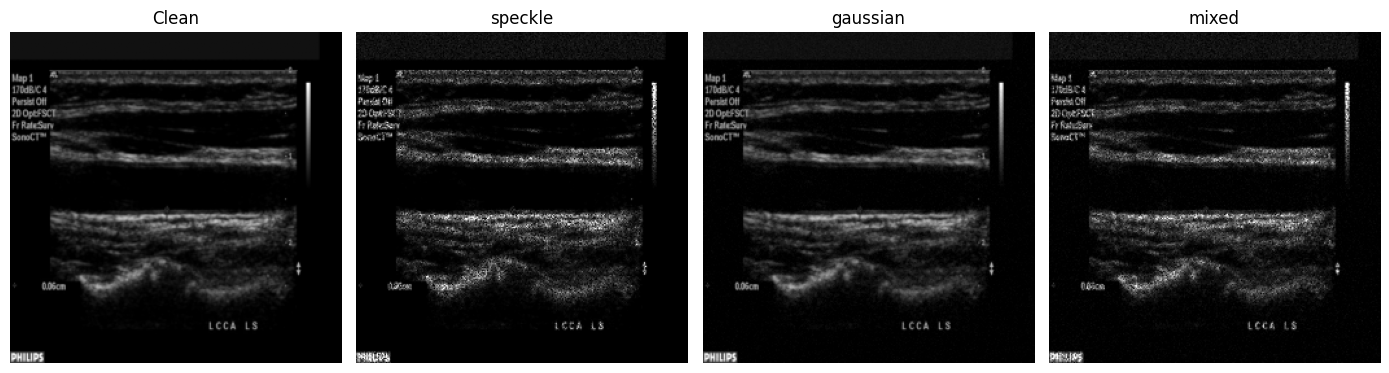

✓ Fixed validation noise confirmed deterministic across rebuilds.


In [11]:
# Sanity check: preview a clean/noisy pair and the three noise types
_sample_path = train_paths[0]
_sample_img = np.asarray(get_eval_augment(CFG_BASE['img_size'])(Image.open(_sample_path).convert('L')), dtype=np.float32) / 255.0
preview_noise_types(_sample_img, CFG_BASE)

# Confirm the fixed val set is genuinely deterministic
_check_a = build_fixed_val_batches(val_paths[:2], CFG_BASE, batch_size=2)[0]['noisy']
_check_b = build_fixed_val_batches(val_paths[:2], CFG_BASE, batch_size=2)[0]['noisy']
assert torch.allclose(_check_a, _check_b), 'Fixed val set is not deterministic!'
print('✓ Fixed validation noise confirmed deterministic across rebuilds.')

## 7. Functional model-dict helpers

Small utilities so a "model" can just be a plain `dict` of `nn.Module` / `nn.Parameter` objects instead of an `nn.Module`
subclass — move to device, save/load state, toggle train/eval, freeze/unfreeze, gather trainable params. Shared by all four
models below.


In [12]:
def move_model_dict_to_device(d, device):
    if isinstance(d, dict):
        for k, v in d.items():
            d[k] = move_model_dict_to_device(v, device)
        return d
    elif isinstance(d, list):
        return [move_model_dict_to_device(v, device) for v in d]
    elif isinstance(d, nn.Module):
        return d.to(device)
    elif isinstance(d, nn.Parameter):
        d.data = d.data.to(device)
        return d
    else:
        return d


def serialize_functional_state(d):
    if isinstance(d, dict):
        return {k: serialize_functional_state(v) for k, v in d.items()}
    elif isinstance(d, list):
        return [serialize_functional_state(v) for v in d]
    elif isinstance(d, nn.Module):
        return d.state_dict()
    elif isinstance(d, nn.Parameter):
        return d.data.cpu()
    else:
        return d


def load_functional_state(saved, target):
    if isinstance(target, dict):
        for k in target:
            load_functional_state(saved[k], target[k])
    elif isinstance(target, list):
        for s, t in zip(saved, target):
            load_functional_state(s, t)
    elif isinstance(target, nn.Module):
        target.load_state_dict(saved)
    elif isinstance(target, nn.Parameter):
        target.data.copy_(saved.to(target.device))


def set_module_tree_eval_or_train(d, train: bool):
    if isinstance(d, dict):
        for v in d.values():
            set_module_tree_eval_or_train(v, train)
    elif isinstance(d, list):
        for v in d:
            set_module_tree_eval_or_train(v, train)
    elif isinstance(d, nn.Module):
        d.train(train)


def set_requires_grad(d, requires_grad: bool):
    if isinstance(d, dict):
        for v in d.values():
            set_requires_grad(v, requires_grad)
    elif isinstance(d, list):
        for v in d:
            set_requires_grad(v, requires_grad)
    elif isinstance(d, nn.Module):
        for p in d.parameters():
            p.requires_grad = requires_grad
    elif isinstance(d, nn.Parameter):
        d.requires_grad = requires_grad


def gather_params(d):
    params = []
    if isinstance(d, dict):
        for v in d.values():
            params += gather_params(v)
    elif isinstance(d, list):
        for v in d:
            params += gather_params(v)
    elif isinstance(d, nn.Module):
        params += [p for p in d.parameters() if p.requires_grad]
    elif isinstance(d, nn.Parameter):
        if d.requires_grad:
            params.append(d)
    return params

print('Functional model-dict helpers defined.')

Functional model-dict helpers defined.


## 8. US-JEPA Encoder (shared by all four models)

Copied architecture-for-architecture from the pretraining notebook. Do not change without re-deriving the checkpoint.


In [13]:
def init_patch_embed(in_channels=1, embed_dim=384, patch_size=16):
    return nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)


def patch_embed_forward(x, proj_layer):
    x = proj_layer(x)   # (B, D, g, g)
    return rearrange(x, 'b d h w -> b (h w) d')


def init_transformer_block(embed_dim, n_heads, mlp_ratio=4.0, dropout=0.0):
    hidden = int(embed_dim * mlp_ratio)
    return nn.ModuleDict({
        'norm1': nn.LayerNorm(embed_dim),
        'attn': nn.MultiheadAttention(embed_dim, n_heads, dropout=dropout, batch_first=True),
        'norm2': nn.LayerNorm(embed_dim),
        'mlp': nn.Sequential(
            nn.Linear(embed_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim), nn.Dropout(dropout),
        )
    })


def transformer_block_forward(x, layers):
    n = layers['norm1'](x)
    attn_out, _ = layers['attn'](n, n, n, need_weights=False)
    x = x + attn_out
    x = x + layers['mlp'](layers['norm2'](x))
    return x


def init_vit_encoder(img_size=224, patch_size=16, in_channels=1, embed_dim=384, depth=8, n_heads=6):
    patch_embed = init_patch_embed(in_channels, embed_dim, patch_size)
    grid_size = img_size // patch_size
    n_patches = grid_size ** 2
    cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
    pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
    blocks = [init_transformer_block(embed_dim, n_heads) for _ in range(depth)]
    norm = nn.LayerNorm(embed_dim)
    return {
        'patch_embed': patch_embed, 'cls_token': cls_token, 'pos_embed': pos_embed,
        'blocks': blocks, 'norm': norm, 'grid_size': grid_size, 'n_patches': n_patches,
    }


def vit_encoder_forward(x, encoder_layers, context_mask=None):
    tokens = patch_embed_forward(x, encoder_layers['patch_embed'])
    B, N, D = tokens.shape
    cls = encoder_layers['cls_token'].expand(B, -1, -1)
    tokens = torch.cat([cls, tokens], dim=1)
    tokens = tokens + encoder_layers['pos_embed']

    if context_mask is not None:
        keep = torch.cat([torch.ones(B, 1, dtype=torch.bool, device=x.device), context_mask], dim=1)
        tokens_list = [tokens[b][keep[b]] for b in range(B)]
        max_len = max(t.shape[0] for t in tokens_list)
        padded = torch.zeros(B, max_len, D, device=x.device, dtype=tokens.dtype)
        for b, t in enumerate(tokens_list):
            padded[b, :t.shape[0]] = t
        tokens = padded

    for block in encoder_layers['blocks']:
        tokens = transformer_block_forward(tokens, block)
    return encoder_layers['norm'](tokens)


def load_pretrained_encoder(cfg, weights_path, device):
    """Rebuilds the exact US-JEPA encoder architecture and loads pretrained weights."""
    encoder = init_vit_encoder(
        img_size=cfg['img_size'], patch_size=cfg['patch_size'],
        in_channels=cfg['img_channels'], embed_dim=cfg['embed_dim'],
        depth=cfg['encoder_depth'], n_heads=cfg['encoder_heads'],
    )
    encoder = move_model_dict_to_device(encoder, device)
    saved = torch.load(weights_path, map_location=device)
    load_functional_state(saved, encoder)
    print(f'✓ Pretrained encoder loaded from {weights_path}')
    return encoder


# ── Load the shared, primary encoder copy (used by Model A) ─────────────────
encoder = load_pretrained_encoder(CFG_BASE, CFG_BASE['pretrained_encoder_path'], DEVICE)
set_requires_grad(encoder, requires_grad=not CFG_BASE['freeze_encoder'])
set_module_tree_eval_or_train(encoder, train=not CFG_BASE['freeze_encoder'])

n_encoder_params = sum(p.numel() for p in gather_params({'encoder': encoder}))
print(f'freeze_encoder = {CFG_BASE["freeze_encoder"]} | trainable encoder params = {n_encoder_params:,}')

✓ Pretrained encoder loaded from /kaggle/input/datasets/onsgui/checkpoints/checkpoints/encoder_best.pth
freeze_encoder = True | trainable encoder params = 0


## 9. Model A — US-JEPA Encoder + Visual-Mamba Decoder

Pure-PyTorch bidirectional selective-scan block (no `mamba-ssm` CUDA kernel dependency). Scan forced to fp32 regardless of the
outer autocast context. Config: `CFG_A_SMALL` (`mamba_depth=2`, `mamba_expand=1`, pure `w_l1` loss).


In [14]:
def init_mamba_block(dim, state_dim=16, expand=2):
    inner_dim = dim * expand
    return {
        'norm': nn.LayerNorm(dim),
        'in_proj': nn.Linear(dim, inner_dim * 2),
        'conv1d': nn.Conv1d(inner_dim, inner_dim, kernel_size=3, padding=1, groups=inner_dim),
        'x_proj_fwd': nn.Linear(inner_dim, state_dim * 2 + 1),
        'x_proj_bwd': nn.Linear(inner_dim, state_dim * 2 + 1),
        'A_log_fwd': nn.Parameter(torch.log(torch.arange(1, state_dim + 1, dtype=torch.float32).repeat(inner_dim, 1))),
        'A_log_bwd': nn.Parameter(torch.log(torch.arange(1, state_dim + 1, dtype=torch.float32).repeat(inner_dim, 1))),
        'D': nn.Parameter(torch.ones(inner_dim)),
        'out_proj': nn.Linear(inner_dim, dim),
    }, inner_dim, state_dim


def mamba_selective_scan(x, layers, inner_dim, state_dim, reverse=False):
    orig_dtype = x.dtype
    with torch.cuda.amp.autocast(enabled=False):
        x = x.float()
        if reverse:
            x = x.flip(dims=[1])
        Bsz, L, _ = x.shape
        proj = layers['x_proj'].float()(x)
        Bmat, Cmat, delta = torch.split(proj, [state_dim, state_dim, 1], dim=-1)
        delta = F.softplus(delta)
        A = -torch.exp(layers['A_log'].float())
        h = torch.zeros(Bsz, inner_dim, state_dim, device=x.device, dtype=torch.float32)
        ys = []
        for t in range(L):
            dt = delta[:, t]
            dA = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0))
            dB = dt.unsqueeze(-1) * Bmat[:, t].unsqueeze(1)
            h = h * dA + dB * x[:, t].unsqueeze(-1)
            y_t = (h * Cmat[:, t].unsqueeze(1)).sum(-1)
            ys.append(y_t)
        y = torch.stack(ys, dim=1)
        y = y + x * layers['D'].float()
        if reverse:
            y = y.flip(dims=[1])
    return y.to(orig_dtype)


def mamba_block_forward(x, layers, inner_dim, state_dim):
    residual = x
    x = layers['norm'](x)
    x_and_gate = layers['in_proj'](x)
    x_in, gate = x_and_gate.chunk(2, dim=-1)
    x_conv = rearrange(x_in, 'b l d -> b d l')
    x_conv = layers['conv1d'](x_conv)[:, :, :x_in.shape[1]]
    x_conv = rearrange(x_conv, 'b d l -> b l d')
    x_conv = F.silu(x_conv)

    y_fwd = mamba_selective_scan(x_conv, {'x_proj': layers['x_proj_fwd'], 'A_log': layers['A_log_fwd'], 'D': layers['D']}, inner_dim, state_dim, reverse=False)
    y_bwd = mamba_selective_scan(x_conv, {'x_proj': layers['x_proj_bwd'], 'A_log': layers['A_log_bwd'], 'D': layers['D']}, inner_dim, state_dim, reverse=True)
    y = (y_fwd + y_bwd) * 0.5

    y = y * F.silu(gate)
    y = layers['out_proj'](y)
    return residual + y


def init_mamba_stack(dim, depth=4, state_dim=16, expand=2):
    blocks, dims = [], None
    for _ in range(depth):
        block, inner_dim, sdim = init_mamba_block(dim, state_dim, expand)
        blocks.append(block)
        dims = (inner_dim, sdim)
    return {'blocks': blocks, 'inner_dim': dims[0], 'state_dim': dims[1]}


def mamba_stack_forward(x, stack_dict):
    for block in stack_dict['blocks']:
        x = mamba_block_forward(x, block, stack_dict['inner_dim'], stack_dict['state_dim'])
    return x


def init_recon_decoder(embed_dim, patch_size=16, out_channels=1, dropout=0.1):
    """Patch-token grid -> full-resolution image via a small ConvTranspose stack."""
    return nn.Sequential(
        nn.ConvTranspose2d(embed_dim, 256, 2, 2), nn.GroupNorm(8, 256), nn.GELU(), nn.Dropout2d(dropout),
        nn.ConvTranspose2d(256, 128, 2, 2), nn.GroupNorm(8, 128), nn.GELU(), nn.Dropout2d(dropout),
        nn.ConvTranspose2d(128, 64, 2, 2), nn.GroupNorm(8, 64), nn.GELU(), nn.Dropout2d(dropout),
        nn.ConvTranspose2d(64, 32, 2, 2), nn.GroupNorm(8, 32), nn.GELU(),
        nn.Conv2d(32, out_channels, 3, padding=1),
        nn.Sigmoid(),
    )


def init_model_a(cfg):
    mamba_stack = init_mamba_stack(cfg['embed_dim'], depth=cfg['mamba_depth'],
                                    state_dim=cfg['mamba_state_dim'], expand=cfg['mamba_expand'])
    decoder = init_recon_decoder(cfg['embed_dim'], cfg['patch_size'], cfg['img_channels'],
                                  dropout=cfg.get('decoder_dropout', 0.0))
    grid_size = cfg['img_size'] // cfg['patch_size']
    return {'mamba': mamba_stack, 'decoder': decoder, 'grid_size': grid_size}


def recon_decoder_forward(patch_tokens, decoder, grid_size):
    B, N, D = patch_tokens.shape
    x = rearrange(patch_tokens, 'b (h w) d -> b d h w', h=grid_size, w=grid_size)
    return decoder(x)


def model_a_forward(noisy_img, encoder_dict, model_a_dict):
    tokens = vit_encoder_forward(noisy_img, encoder_dict, context_mask=None)
    patch_tokens = tokens[:, 1:]
    mixed = mamba_stack_forward(patch_tokens, model_a_dict['mamba'])
    mixed = mixed + patch_tokens  # residual around the Mamba stack
    denoised = recon_decoder_forward(mixed, model_a_dict['decoder'], model_a_dict['grid_size'])
    return denoised


model_a_small = init_model_a(CFG_A_SMALL)
model_a_small = move_model_dict_to_device(model_a_small, DEVICE)
n_params_a = sum(p.numel() for p in gather_params(model_a_small))
print(f'Model A (Visual Mamba) decoder+mixer params: {n_params_a:,}')

Model A (Visual Mamba) decoder+mixer params: 1,534,789


## 10. Model B — US-JEPA Encoder + Physics-Informed Decoder

Conv upsampling stack with a speckle-gating branch: a per-pixel gate blends a "smooth" branch and a "detail" branch, letting
the network smooth harder in speckle-dominated homogeneous regions while preserving detail near edges.


In [15]:
def init_speckle_gate(channels):
    return nn.Sequential(
        nn.Conv2d(channels, channels // 2, 3, padding=1), nn.GELU(),
        nn.Conv2d(channels // 2, 1, 3, padding=1), nn.Sigmoid(),
    )


def init_physics_decoder(embed_dim, out_channels=1, dropout=0.1):
    up = nn.Sequential(
        nn.ConvTranspose2d(embed_dim, 256, 2, 2), nn.GroupNorm(8, 256), nn.GELU(), nn.Dropout2d(dropout),
        nn.ConvTranspose2d(256, 128, 2, 2), nn.GroupNorm(8, 128), nn.GELU(), nn.Dropout2d(dropout),
        nn.ConvTranspose2d(128, 64, 2, 2), nn.GroupNorm(8, 64), nn.GELU(), nn.Dropout2d(dropout),
        nn.ConvTranspose2d(64, 32, 2, 2), nn.GroupNorm(8, 32), nn.GELU(),
    )
    gate = init_speckle_gate(32)
    smooth_branch = nn.Conv2d(32, out_channels, 5, padding=2)
    detail_branch = nn.Conv2d(32, out_channels, 3, padding=1)
    return {'up': up, 'gate': gate, 'smooth_branch': smooth_branch, 'detail_branch': detail_branch}


def physics_decoder_forward(patch_tokens, decoder_dict, grid_size):
    B, N, D = patch_tokens.shape
    x = rearrange(patch_tokens, 'b (h w) d -> b d h w', h=grid_size, w=grid_size)
    feat = decoder_dict['up'](x)
    gate = decoder_dict['gate'](feat)
    smooth_out = decoder_dict['smooth_branch'](feat)
    detail_out = decoder_dict['detail_branch'](feat)
    out = gate * smooth_out + (1 - gate) * detail_out
    return torch.sigmoid(out), gate


def init_model_b(cfg):
    decoder = init_physics_decoder(cfg['embed_dim'], cfg['img_channels'], dropout=cfg.get('decoder_dropout', 0.0))
    grid_size = cfg['img_size'] // cfg['patch_size']
    return {'decoder': decoder, 'grid_size': grid_size}


def model_b_forward(noisy_img, encoder_dict, model_b_dict, return_gate=False):
    tokens = vit_encoder_forward(noisy_img, encoder_dict, context_mask=None)
    patch_tokens = tokens[:, 1:]
    denoised, gate = physics_decoder_forward(patch_tokens, model_b_dict['decoder'], model_b_dict['grid_size'])
    if return_gate:
        return denoised, gate
    return denoised


model_b = init_model_b(CFG_B)
model_b = move_model_dict_to_device(model_b, DEVICE)
n_params_b = sum(p.numel() for p in gather_params(model_b))
print(f'Model B (Physics-Informed) decoder params: {n_params_b:,}')

Model B (Physics-Informed) decoder params: 572,547


## 11. Model C — US-JEPA Encoder + U-Net Decoder

Same functional convention as A/B. Multi-scale skip connections come from **downsampled copies of the noisy input** at each
up-block's output resolution (the shared US-JEPA encoder only exposes final patch tokens, not intermediate feature maps, so
this keeps the true U-Net skip-connection idea while using exactly the same encoder as every other model). Predicts a residual
correction on top of a bilinearly-upsampled copy of the noisy input, exactly like `01`. `unet_channels` unchanged from `01`.


In [16]:
def init_residual_conv_block(channels, dropout=0.1):
    return {
        'conv1': nn.Conv2d(channels, channels, 3, padding=1),
        'norm1': nn.GroupNorm(8, channels),
        'conv2': nn.Conv2d(channels, channels, 3, padding=1),
        'norm2': nn.GroupNorm(8, channels),
        'drop': nn.Dropout2d(dropout),
    }


def residual_conv_block_forward(x, layers):
    residual = x
    x = F.gelu(layers['norm1'](layers['conv1'](x)))
    x = layers['drop'](x)
    x = layers['norm2'](layers['conv2'](x))
    return F.gelu(x + residual)


def init_unet_up_block(in_ch, skip_ch, out_ch, dropout=0.1):
    return {
        'up': nn.ConvTranspose2d(in_ch, out_ch, 2, 2),
        'skip_proj': nn.Conv2d(skip_ch, out_ch, 1),
        'fuse': nn.Conv2d(out_ch * 2, out_ch, 3, padding=1),
        'norm': nn.GroupNorm(8, out_ch),
        'refine': init_residual_conv_block(out_ch, dropout),
    }


def unet_up_block_forward(x, skip, layers):
    x = layers['up'](x)
    skip = layers['skip_proj'](skip)
    if skip.shape[-2:] != x.shape[-2:]:
        skip = F.interpolate(skip, size=x.shape[-2:], mode='bilinear', align_corners=False)
    x = F.gelu(layers['norm'](layers['fuse'](torch.cat([x, skip], dim=1))))
    return residual_conv_block_forward(x, layers['refine'])


def init_model_c(cfg):
    channels = cfg['unet_channels']          # unchanged from 01: (256, 128, 64, 32)
    n_up = int(math.log2(cfg['patch_size']))  # number of 2x up-stages needed to reach full resolution
    in_conv = nn.Conv2d(cfg['embed_dim'], channels[0], 3, padding=1)
    up_blocks = []
    ch = channels[0]
    for i in range(n_up):
        next_ch = channels[min(i + 1, len(channels) - 1)]
        up_blocks.append(init_unet_up_block(ch, cfg['img_channels'], next_ch, dropout=cfg.get('decoder_dropout', 0.0)))
        ch = next_ch
    out_conv = nn.Sequential(
        nn.Conv2d(ch, ch, 3, padding=1), nn.GELU(),
        nn.Conv2d(ch, cfg['img_channels'], 3, padding=1),
    )
    grid_size = cfg['img_size'] // cfg['patch_size']
    return {'in_conv': in_conv, 'up_blocks': up_blocks, 'out_conv': out_conv, 'grid_size': grid_size}


def model_c_forward(noisy_img, encoder_dict, model_c_dict):
    tokens = vit_encoder_forward(noisy_img, encoder_dict, context_mask=None)
    patch_tokens = tokens[:, 1:]
    grid_size = model_c_dict['grid_size']
    x = rearrange(patch_tokens, 'b (h w) d -> b d h w', h=grid_size, w=grid_size)

    h = model_c_dict['in_conv'](x)
    for block in model_c_dict['up_blocks']:
        target_size = (h.shape[-2] * 2, h.shape[-1] * 2)
        skip = F.interpolate(noisy_img, size=target_size, mode='bilinear', align_corners=False)
        h = unet_up_block_forward(h, skip, block)

    residual = model_c_dict['out_conv'](h)
    upsampled_input = F.interpolate(noisy_img, size=residual.shape[-2:], mode='bilinear', align_corners=False)
    return upsampled_input + residual


model_c = init_model_c(CFG_C)
model_c = move_model_dict_to_device(model_c, DEVICE)
n_params_c = sum(p.numel() for p in gather_params(model_c))
print(f'Model C (U-Net) decoder params: {n_params_c:,}')

Model C (U-Net) decoder params: 1,884,737


## 12. Model D — US-JEPA Encoder + Restormer Decoder

MDTA (channel-wise attention, linear in image resolution) + GDFN (gated feed-forward), same up-block pattern as Model C but
with Restormer blocks for refinement instead of plain residual conv blocks. `restormer_heads` / `restormer_ffn_expansion`
unchanged from `01`.


In [17]:
def init_channel_layernorm(channels):
    return nn.LayerNorm(channels)


def channel_layernorm_forward(x, ln):
    x = x.permute(0, 2, 3, 1)
    x = ln(x)
    return x.permute(0, 3, 1, 2)


def init_mdta(dim, num_heads):
    return {
        'temperature': nn.Parameter(torch.ones(num_heads, 1, 1)),
        'qkv': nn.Conv2d(dim, dim * 3, 1),
        'qkv_dwconv': nn.Conv2d(dim * 3, dim * 3, 3, padding=1, groups=dim * 3),
        'project_out': nn.Conv2d(dim, dim, 1),
        'num_heads': num_heads,
    }


def mdta_forward(x, layers):
    B, C, H, W = x.shape
    num_heads = layers['num_heads']
    qkv = layers['qkv_dwconv'](layers['qkv'](x))
    q, k, v = qkv.chunk(3, dim=1)

    head_dim = C // num_heads
    q = q.reshape(B, num_heads, head_dim, H * W)
    k = k.reshape(B, num_heads, head_dim, H * W)
    v = v.reshape(B, num_heads, head_dim, H * W)

    q = F.normalize(q, dim=-1)
    k = F.normalize(k, dim=-1)

    attn = (q @ k.transpose(-2, -1)) * layers['temperature']
    attn = attn.softmax(dim=-1)
    out = (attn @ v).reshape(B, C, H, W)
    return layers['project_out'](out)


def init_gdfn(dim, expansion=2.66, dropout=0.1):
    hidden = int(dim * expansion)
    return {
        'project_in': nn.Conv2d(dim, hidden * 2, 1),
        'dwconv': nn.Conv2d(hidden * 2, hidden * 2, 3, padding=1, groups=hidden * 2),
        'drop': nn.Dropout2d(dropout),
        'project_out': nn.Conv2d(hidden, dim, 1),
    }


def gdfn_forward(x, layers):
    x = layers['project_in'](x)
    x = layers['dwconv'](x)
    gate, value = x.chunk(2, dim=1)
    x = F.gelu(gate) * value
    x = layers['drop'](x)
    return layers['project_out'](x)


def init_restormer_block(dim, num_heads, ffn_expansion=2.66, dropout=0.1):
    return {
        'norm1': init_channel_layernorm(dim),
        'attn': init_mdta(dim, num_heads),
        'norm2': init_channel_layernorm(dim),
        'ffn': init_gdfn(dim, ffn_expansion, dropout),
    }


def restormer_block_forward(x, layers):
    x = x + mdta_forward(channel_layernorm_forward(x, layers['norm1']), layers['attn'])
    x = x + gdfn_forward(channel_layernorm_forward(x, layers['norm2']), layers['ffn'])
    return x


def init_restormer_up_block(in_ch, skip_ch, out_ch, num_heads, ffn_expansion, n_blocks=2, dropout=0.1):
    blocks = [init_restormer_block(out_ch, num_heads, ffn_expansion, dropout) for _ in range(n_blocks)]
    return {
        'up': nn.ConvTranspose2d(in_ch, out_ch, 2, 2),
        'skip_proj': nn.Conv2d(skip_ch, out_ch, 1),
        'fuse': nn.Conv2d(out_ch * 2, out_ch, 1),
        'blocks': blocks,
    }


def restormer_up_block_forward(x, skip, layers):
    x = layers['up'](x)
    skip = layers['skip_proj'](skip)
    if skip.shape[-2:] != x.shape[-2:]:
        skip = F.interpolate(skip, size=x.shape[-2:], mode='bilinear', align_corners=False)
    x = layers['fuse'](torch.cat([x, skip], dim=1))
    for block in layers['blocks']:
        x = restormer_block_forward(x, block)
    return x


def init_model_d(cfg):
    base_ch = 256
    n_up = int(math.log2(cfg['patch_size']))
    num_heads = cfg['restormer_heads']            # unchanged from 01: 8
    ffn_expansion = cfg['restormer_ffn_expansion']  # unchanged from 01: 2.66

    in_conv = nn.Conv2d(cfg['embed_dim'], base_ch, 3, padding=1)
    up_blocks = []
    ch = base_ch
    for i in range(n_up):
        next_ch = max(ch // 2, 16)
        heads = max(1, num_heads // (2 ** i))
        while next_ch % heads != 0 and heads > 1:
            heads -= 1
        up_blocks.append(init_restormer_up_block(ch, cfg['img_channels'], next_ch, heads, ffn_expansion,
                                                  dropout=cfg.get('decoder_dropout', 0.0)))
        ch = next_ch

    out_conv = nn.Sequential(
        nn.Conv2d(ch, ch, 3, padding=1), nn.GELU(),
        nn.Conv2d(ch, cfg['img_channels'], 3, padding=1),
    )
    grid_size = cfg['img_size'] // cfg['patch_size']
    return {'in_conv': in_conv, 'up_blocks': up_blocks, 'out_conv': out_conv, 'grid_size': grid_size}


def model_d_forward(noisy_img, encoder_dict, model_d_dict):
    tokens = vit_encoder_forward(noisy_img, encoder_dict, context_mask=None)
    patch_tokens = tokens[:, 1:]
    grid_size = model_d_dict['grid_size']
    x = rearrange(patch_tokens, 'b (h w) d -> b d h w', h=grid_size, w=grid_size)

    h = model_d_dict['in_conv'](x)
    for block in model_d_dict['up_blocks']:
        target_size = (h.shape[-2] * 2, h.shape[-1] * 2)
        skip = F.interpolate(noisy_img, size=target_size, mode='bilinear', align_corners=False)
        h = restormer_up_block_forward(h, skip, block)

    residual = model_d_dict['out_conv'](h)
    upsampled_input = F.interpolate(noisy_img, size=residual.shape[-2:], mode='bilinear', align_corners=False)
    return upsampled_input + residual


model_d = init_model_d(CFG_D)
model_d = move_model_dict_to_device(model_d, DEVICE)
n_params_d = sum(p.numel() for p in gather_params(model_d))
print(f'Model D (Restormer) decoder params: {n_params_d:,}')

Model D (Restormer) decoder params: 1,673,627


## 13. Loss Functions

```
Total Loss = w_l1 · L1 + w_ssim · (1 − SSIM) + w_edge · EdgeLoss
           + w_speckle_reg · SpeckleRegularization + w_smooth · SmoothnessLoss + w_mse · MSE
```
Every term is independently toggleable via its weight in whichever `cfg` is passed in. Model A uses only `w_l1`; Model B uses
the full physics stack; Models C/D use `w_l1` + `w_ssim` (matching `01`'s `loss_alpha_l1` / `loss_beta_ssim`).


In [18]:
def l1_loss(pred, target):
    return F.l1_loss(pred, target)


def ssim_loss(pred, target):
    """1 - SSIM, differentiable, so a *lower* value is better."""
    return 1.0 - ssim_metric(pred, target, data_range=1.0, size_average=True)


def sobel_edges(img):
    kx = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=img.dtype, device=img.device).view(1, 1, 3, 3)
    ky = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=img.dtype, device=img.device).view(1, 1, 3, 3)
    gx = F.conv2d(img, kx, padding=1)
    gy = F.conv2d(img, ky, padding=1)
    return torch.sqrt(gx ** 2 + gy ** 2 + 1e-6)


def edge_preservation_loss(pred, target):
    return F.l1_loss(sobel_edges(pred), sobel_edges(target))


def speckle_aware_regularization(pred, noisy):
    tv_h = (pred[:, :, 1:, :] - pred[:, :, :-1, :]).abs()
    tv_w = (pred[:, :, :, 1:] - pred[:, :, :, :-1]).abs()
    with torch.no_grad():
        local_var = F.avg_pool2d(noisy ** 2, 5, stride=1, padding=2) - F.avg_pool2d(noisy, 5, stride=1, padding=2) ** 2
        low_var_weight = torch.exp(-local_var * 10.0)
    weight_h = low_var_weight[:, :, 1:, :]
    weight_w = low_var_weight[:, :, :, 1:]
    return (tv_h * weight_h).mean() + (tv_w * weight_w).mean()


def smoothness_loss(pred):
    tv_h = (pred[:, :, 1:, :] - pred[:, :, :-1, :]).pow(2).mean()
    tv_w = (pred[:, :, :, 1:] - pred[:, :, :, :-1]).pow(2).mean()
    return tv_h + tv_w


def total_loss(pred, target, noisy, cfg):
    """Combines all terms according to their CFG weights (missing weights default to 0). Returns (total, dict_of_components)."""
    components = {}
    total = 0.0
    if cfg.get('w_l1', 0.0) > 0:
        components['l1'] = l1_loss(pred, target)
        total = total + cfg['w_l1'] * components['l1']
    if cfg.get('w_mse', 0.0) > 0:
        components['mse'] = F.mse_loss(pred, target)
        total = total + cfg['w_mse'] * components['mse']
    if cfg.get('w_ssim', 0.0) > 0:
        components['ssim'] = ssim_loss(pred, target)
        total = total + cfg['w_ssim'] * components['ssim']
    if cfg.get('w_edge', 0.0) > 0:
        components['edge'] = edge_preservation_loss(pred, target)
        total = total + cfg['w_edge'] * components['edge']
    if cfg.get('w_speckle_reg', 0.0) > 0:
        components['speckle_reg'] = speckle_aware_regularization(pred, noisy)
        total = total + cfg['w_speckle_reg'] * components['speckle_reg']
    if cfg.get('w_smooth', 0.0) > 0:
        components['smooth'] = smoothness_loss(pred)
        total = total + cfg['w_smooth'] * components['smooth']
    components['total'] = total
    return total, components

print('Loss functions defined.')

Loss functions defined.


## 14. Validation Metrics — PSNR, SSIM, LPIPS

LPIPS uses an AlexNet backbone trained on natural RGB photographs, not ultrasound imagery — used as a rough perceptual-similarity
proxy (replicated to 3 channels). Treat LPIPS numbers here as directional rather than domain-validated. PSNR/SSIM are the
primary, more trustworthy metrics for this data.


In [19]:
_lpips_fn = lpips.LPIPS(net='alex').to(DEVICE).eval()
for p in _lpips_fn.parameters():
    p.requires_grad = False


def compute_psnr(pred, target):
    mse = F.mse_loss(pred, target).item()
    if mse == 0:
        return 99.0
    return 10 * math.log10(1.0 / mse)


def compute_ssim(pred, target):
    return ssim_metric(pred, target, data_range=1.0, size_average=True).item()


def compute_lpips(pred, target):
    """LPIPS expects 3-channel images in [-1, 1]."""
    pred3 = pred.repeat(1, 3, 1, 1) * 2 - 1
    target3 = target.repeat(1, 3, 1, 1) * 2 - 1
    with torch.no_grad():
        return _lpips_fn(pred3, target3).mean().item()

print('Metric functions defined.')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 192MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Metric functions defined.


## 15. Generic Training Pipeline

A single `train(...)` function works for **all four architectures** — it takes a `forward_fn(noisy, encoder, model_dict) ->
denoised` closure so every model trains through the exact same loop (tqdm progress, AMP, LR scheduler, checkpointing, early
stopping, TensorBoard, loss history). `validate()` always scores against the fixed noisy validation batches.


In [20]:
def validate(model_dict, forward_fn, encoder_dict, cfg, fixed_batches):
    set_module_tree_eval_or_train(model_dict, train=False)
    set_module_tree_eval_or_train(encoder_dict, train=False)

    total_loss_sum, psnr_sum, ssim_sum, lpips_sum, n = 0.0, 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        for batch in fixed_batches:
            noisy = batch['noisy'].to(DEVICE)
            clean = batch['clean'].to(DEVICE)

            pred = forward_fn(noisy, encoder_dict, model_dict)
            pred = pred.clamp(0, 1)

            loss, _ = total_loss(pred, clean, noisy, cfg)
            total_loss_sum += loss.item() * noisy.size(0)
            psnr_sum += compute_psnr(pred, clean) * noisy.size(0)
            ssim_sum += compute_ssim(pred, clean) * noisy.size(0)
            lpips_sum += compute_lpips(pred, clean) * noisy.size(0)
            n += noisy.size(0)

    return total_loss_sum / n, psnr_sum / n, ssim_sum / n, lpips_sum / n


print('validate() defined.')

validate() defined.


In [21]:
def train(model_name, model_dict, forward_fn, encoder_dict, cfg, train_loader, fixed_val_batches):
    """Generic training loop, shared by all four models.

    Args:
        model_name        : str, used for checkpoint filenames / TB run name / prints
        model_dict         : the decoder(+mixer) functional dict for this model
        forward_fn         : function(noisy_img, encoder_dict, model_dict) -> denoised_img
        encoder_dict       : the US-JEPA encoder copy for this model (frozen or trainable per cfg)
        cfg                : CFG_A_SMALL / CFG_B / CFG_C / CFG_D — controls schedule + loss weights
        fixed_val_batches  : FIXED_VAL_BATCHES built once in Section 6

    Returns:
        history dict, best_val_psnr, elapsed_seconds
    """
    params = gather_params(model_dict) + gather_params({'encoder': encoder_dict})
    optimizer = torch.optim.AdamW(params, lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg['mixed_precision'] and torch.cuda.is_available()))
    writer = SummaryWriter(os.path.join(cfg['log_dir'], model_name)) if TENSORBOARD else None

    history = {'train_loss': [], 'val_loss': [], 'val_psnr': [], 'val_ssim': [], 'val_lpips': []}
    best_val_psnr = -1.0
    epochs_no_improve = 0

    ckpt_dir = os.path.join(cfg['checkpoint_dir'], model_name)
    os.makedirs(ckpt_dir, exist_ok=True)

    start_time = time.time()
    for epoch in range(1, cfg['epochs'] + 1):
        set_module_tree_eval_or_train(model_dict, train=True)
        if not cfg['freeze_encoder']:
            set_module_tree_eval_or_train(encoder_dict, train=True)

        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f'[{model_name}] Epoch {epoch}/{cfg["epochs"]}')
        for batch in pbar:
            noisy = batch['noisy'].to(DEVICE, non_blocking=True)
            clean = batch['clean'].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(cfg['mixed_precision'] and torch.cuda.is_available())):
                pred = forward_fn(noisy, encoder_dict, model_dict)
                loss, _ = total_loss(pred, clean, noisy, cfg)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, cfg['grad_clip_norm'])
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}')

        scheduler.step()
        train_loss = running_loss / len(train_loader)

        val_loss, val_psnr, val_ssim, val_lpips = validate(model_dict, forward_fn, encoder_dict, cfg, fixed_val_batches)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_psnr'].append(val_psnr)
        history['val_ssim'].append(val_ssim)
        history['val_lpips'].append(val_lpips)

        print(f'[{model_name}] Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} '
              f'PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} LPIPS={val_lpips:.4f}')

        if writer:
            writer.add_scalar('loss/train', train_loss, epoch)
            writer.add_scalar('loss/val', val_loss, epoch)
            writer.add_scalar('metrics/psnr', val_psnr, epoch)
            writer.add_scalar('metrics/ssim', val_ssim, epoch)
            writer.add_scalar('metrics/lpips', val_lpips, epoch)

        last_ckpt = {
            'epoch': epoch,
            'model': serialize_functional_state(model_dict),
            'encoder': serialize_functional_state(encoder_dict) if not cfg['freeze_encoder'] else None,
            'history': history,
        }
        torch.save(last_ckpt, os.path.join(ckpt_dir, 'checkpoint_last.pth'))

        # Smooth val_psnr with an EMA before using it for checkpoint/early-stop decisions.
        ema_alpha = 0.3
        if epoch == 1:
            smoothed_psnr = val_psnr
        else:
            smoothed_psnr = ema_alpha * val_psnr + (1 - ema_alpha) * history.get('_smoothed_psnr', [val_psnr])[-1]
        history.setdefault('_smoothed_psnr', []).append(smoothed_psnr)

        if smoothed_psnr > best_val_psnr:
            best_val_psnr = smoothed_psnr
            epochs_no_improve = 0
            torch.save(last_ckpt, os.path.join(ckpt_dir, 'checkpoint_best.pth'))
            print(f'  ✓ New best smoothed PSNR ({best_val_psnr:.2f}, raw={val_psnr:.2f}) — checkpoint saved.')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= cfg['early_stop_patience']:
                print(f'  Early stopping at epoch {epoch} (no improvement for {cfg["early_stop_patience"]} epochs).')
                break

    elapsed = time.time() - start_time
    if writer:
        writer.close()
    print(f'[{model_name}] Training finished in {elapsed/60:.1f} min. Best val PSNR: {best_val_psnr:.2f}')
    return history, best_val_psnr, elapsed

print('train() defined.')

train() defined.


## 16. Train Model A — Visual Mamba

In [22]:
history_a, best_psnr_a, time_a = train(
    model_name='model_a_visual_mamba',
    model_dict=model_a_small,
    forward_fn=model_a_forward,
    encoder_dict=encoder,
    cfg=CFG_A_SMALL,
    train_loader=train_loader,
    fixed_val_batches=FIXED_VAL_BATCHES,
)

[model_a_visual_mamba] Epoch 1/50: 100%|██████████| 77/77 [01:29<00:00,  1.16s/it, loss=0.0929]


[model_a_visual_mamba] Epoch 1: train_loss=0.1470 val_loss=0.0873 PSNR=16.90 SSIM=0.2429 LPIPS=0.6258
  ✓ New best smoothed PSNR (16.90, raw=16.90) — checkpoint saved.


[model_a_visual_mamba] Epoch 2/50: 100%|██████████| 77/77 [01:10<00:00,  1.09it/s, loss=0.0809]


[model_a_visual_mamba] Epoch 2: train_loss=0.0822 val_loss=0.0785 PSNR=16.92 SSIM=0.3595 LPIPS=0.5941
  ✓ New best smoothed PSNR (16.90, raw=16.92) — checkpoint saved.


[model_a_visual_mamba] Epoch 3/50: 100%|██████████| 77/77 [01:10<00:00,  1.10it/s, loss=0.0699]


...

[model_a_visual_mamba] Epoch 48: train_loss=0.0407 val_loss=0.0414 PSNR=21.47 SSIM=0.5796 LPIPS=0.4157
  ✓ New best smoothed PSNR (21.38, raw=21.47) — checkpoint saved.


[model_a_visual_mamba] Epoch 49/50: 100%|██████████| 77/77 [01:10<00:00,  1.09it/s, loss=0.0419]


[model_a_visual_mamba] Epoch 49: train_loss=0.0407 val_loss=0.0414 PSNR=21.48 SSIM=0.5798 LPIPS=0.4160
  ✓ New best smoothed PSNR (21.41, raw=21.48) — checkpoint saved.


[model_a_visual_mamba] Epoch 50/50: 100%|██████████| 77/77 [01:11<00:00,  1.08it/s, loss=0.0411]


[model_a_visual_mamba] Epoch 50: train_loss=0.0407 val_loss=0.0414 PSNR=21.48 SSIM=0.5800 LPIPS=0.4156
  ✓ New best smoothed PSNR (21.43, raw=21.48) — checkpoint saved.
[model_a_visual_mamba] Training finished in 62.2 min. Best val PSNR: 21.43


## 17. Train Model B — Physics-Informed Decoder

In [23]:
# Fresh encoder copy so Model B starts from the same pretrained weights as Model A
# (rather than whatever Model A may have fine-tuned to, if freeze_encoder=False).
encoder_b = load_pretrained_encoder(CFG_BASE, CFG_BASE['pretrained_encoder_path'], DEVICE)
set_requires_grad(encoder_b, requires_grad=not CFG_BASE['freeze_encoder'])
set_module_tree_eval_or_train(encoder_b, train=not CFG_BASE['freeze_encoder'])

history_b, best_psnr_b, time_b = train(
    model_name='model_b_physics_informed',
    model_dict=model_b,
    forward_fn=model_b_forward,
    encoder_dict=encoder_b,
    cfg=CFG_B,
    train_loader=train_loader,
    fixed_val_batches=FIXED_VAL_BATCHES,
)

✓ Pretrained encoder loaded from /kaggle/input/datasets/onsgui/checkpoints/checkpoints/encoder_best.pth


[model_b_physics_informed] Epoch 1/50: 100%|██████████| 77/77 [00:27<00:00,  2.77it/s, loss=0.4361]


[model_b_physics_informed] Epoch 1: train_loss=0.5951 val_loss=0.4253 PSNR=15.86 SSIM=0.4391 LPIPS=0.6467
  ✓ New best smoothed PSNR (15.86, raw=15.86) — checkpoint saved.


[model_b_physics_informed] Epoch 2/50: 100%|██████████| 77/77 [00:27<00:00,  2.79it/s, loss=0.4366]


[model_b_physics_informed] Epoch 2: train_loss=0.4245 val_loss=0.4194 PSNR=15.90 SSIM=0.4476 LPIPS=0.6328
  ✓ New best smoothed PSNR (15.87, raw=15.90) — checkpoint saved.


...

[model_b_physics_informed] Epoch 48: train_loss=0.3548 val_loss=0.3551 PSNR=19.07 SSIM=0.5100 LPIPS=0.4767
  ✓ New best smoothed PSNR (18.91, raw=19.07) — checkpoint saved.


[model_b_physics_informed] Epoch 49/50: 100%|██████████| 77/77 [00:27<00:00,  2.79it/s, loss=0.3449]


[model_b_physics_informed] Epoch 49: train_loss=0.3542 val_loss=0.3550 PSNR=19.03 SSIM=0.5102 LPIPS=0.4741
  ✓ New best smoothed PSNR (18.94, raw=19.03) — checkpoint saved.


[model_b_physics_informed] Epoch 50/50: 100%|██████████| 77/77 [00:27<00:00,  2.75it/s, loss=0.3583]


[model_b_physics_informed] Epoch 50: train_loss=0.3535 val_loss=0.3548 PSNR=19.04 SSIM=0.5112 LPIPS=0.4768
  ✓ New best smoothed PSNR (18.97, raw=19.04) — checkpoint saved.
[model_b_physics_informed] Training finished in 25.2 min. Best val PSNR: 18.97


## 18. Train Model C — U-Net Decoder

In [24]:

encoder_c = load_pretrained_encoder(CFG_BASE, CFG_BASE['pretrained_encoder_path'], DEVICE)
set_requires_grad(encoder_c, requires_grad=not CFG_BASE['freeze_encoder'])
set_module_tree_eval_or_train(encoder_c, train=not CFG_BASE['freeze_encoder'])

history_c, best_psnr_c, time_c = train(
    model_name='model_c_unet',
    model_dict=model_c,
    forward_fn=model_c_forward,
    encoder_dict=encoder_c,
    cfg=CFG_C,
    train_loader=train_loader,
    fixed_val_batches=FIXED_VAL_BATCHES,
)

✓ Pretrained encoder loaded from /kaggle/input/datasets/onsgui/checkpoints/checkpoints/encoder_best.pth


[model_c_unet] Epoch 1/50: 100%|██████████| 77/77 [00:37<00:00,  2.06it/s, loss=0.2052]


[model_c_unet] Epoch 1: train_loss=0.2738 val_loss=0.1896 PSNR=25.06 SSIM=0.7108 LPIPS=0.2515
  ✓ New best smoothed PSNR (25.06, raw=25.06) — checkpoint saved.


[model_c_unet] Epoch 2/50: 100%|██████████| 77/77 [00:36<00:00,  2.12it/s, loss=0.1873]


[model_c_unet] Epoch 2: train_loss=0.2217 val_loss=0.1751 PSNR=27.53 SSIM=0.7265 LPIPS=0.1908
  ✓ New best smoothed PSNR (25.80, raw=27.53) — checkpoint saved.


...

[model_c_unet] Epoch 48: train_loss=0.0714 val_loss=0.0671 PSNR=30.77 SSIM=0.9137 LPIPS=0.0975
  ✓ New best smoothed PSNR (30.76, raw=30.77) — checkpoint saved.


[model_c_unet] Epoch 49/50: 100%|██████████| 77/77 [00:36<00:00,  2.14it/s, loss=0.0695]


[model_c_unet] Epoch 49: train_loss=0.0713 val_loss=0.0674 PSNR=30.77 SSIM=0.9133 LPIPS=0.0965
  ✓ New best smoothed PSNR (30.76, raw=30.77) — checkpoint saved.


[model_c_unet] Epoch 50/50: 100%|██████████| 77/77 [00:36<00:00,  2.12it/s, loss=0.0740]


[model_c_unet] Epoch 50: train_loss=0.0719 val_loss=0.0671 PSNR=30.77 SSIM=0.9137 LPIPS=0.0967
  ✓ New best smoothed PSNR (30.77, raw=30.77) — checkpoint saved.
[model_c_unet] Training finished in 33.2 min. Best val PSNR: 30.77


## 19. Train Model D — Restormer Decoder

In [25]:
encoder_d = load_pretrained_encoder(CFG_BASE, CFG_BASE['pretrained_encoder_path'], DEVICE)
set_requires_grad(encoder_d, requires_grad=not CFG_BASE['freeze_encoder'])
set_module_tree_eval_or_train(encoder_d, train=not CFG_BASE['freeze_encoder'])

history_d, best_psnr_d, time_d = train(
    model_name='model_d_restormer',
    model_dict=model_d,
    forward_fn=model_d_forward,
    encoder_dict=encoder_d,
    cfg=CFG_D,
    train_loader=train_loader,
    fixed_val_batches=FIXED_VAL_BATCHES,
)

✓ Pretrained encoder loaded from /kaggle/input/datasets/onsgui/checkpoints/checkpoints/encoder_best.pth


[model_d_restormer] Epoch 1/50: 100%|██████████| 77/77 [01:25<00:00,  1.11s/it, loss=0.2205]


[model_d_restormer] Epoch 1: train_loss=0.2448 val_loss=0.2088 PSNR=24.65 SSIM=0.6775 LPIPS=0.2699
  ✓ New best smoothed PSNR (24.65, raw=24.65) — checkpoint saved.


[model_d_restormer] Epoch 2/50: 100%|██████████| 77/77 [01:15<00:00,  1.02it/s, loss=0.2524]


[model_d_restormer] Epoch 2: train_loss=0.2276 val_loss=0.1881 PSNR=24.93 SSIM=0.7136 LPIPS=0.2525
  ✓ New best smoothed PSNR (24.73, raw=24.93) — checkpoint saved.


...

[model_d_restormer] Epoch 48: train_loss=0.0752 val_loss=0.0724 PSNR=30.10 SSIM=0.9067 LPIPS=0.1266
  ✓ New best smoothed PSNR (30.09, raw=30.10) — checkpoint saved.


[model_d_restormer] Epoch 49/50: 100%|██████████| 77/77 [01:14<00:00,  1.03it/s, loss=0.0751]


[model_d_restormer] Epoch 49: train_loss=0.0756 val_loss=0.0723 PSNR=30.10 SSIM=0.9069 LPIPS=0.1265
  ✓ New best smoothed PSNR (30.09, raw=30.10) — checkpoint saved.


[model_d_restormer] Epoch 50/50: 100%|██████████| 77/77 [01:14<00:00,  1.04it/s, loss=0.0786]


[model_d_restormer] Epoch 50: train_loss=0.0752 val_loss=0.0723 PSNR=30.10 SSIM=0.9069 LPIPS=0.1265
  ✓ New best smoothed PSNR (30.09, raw=30.10) — checkpoint saved.
[model_d_restormer] Training finished in 68.4 min. Best val PSNR: 30.09


## 20. Training Curves

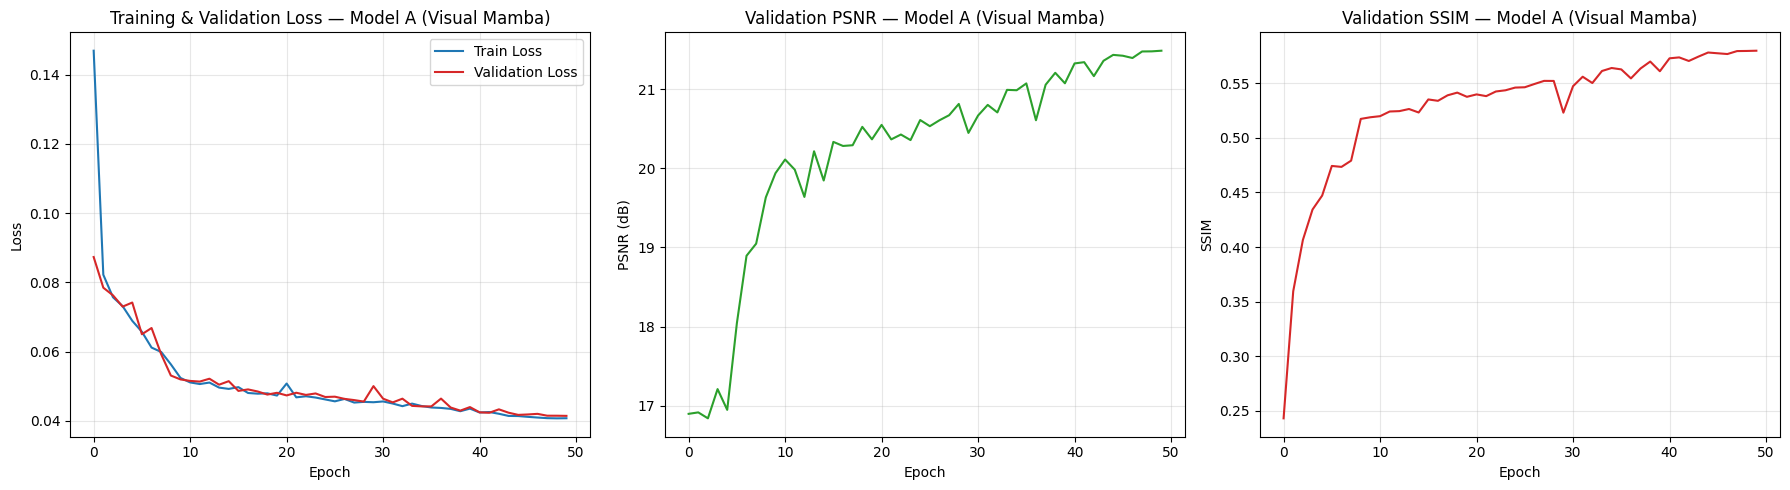

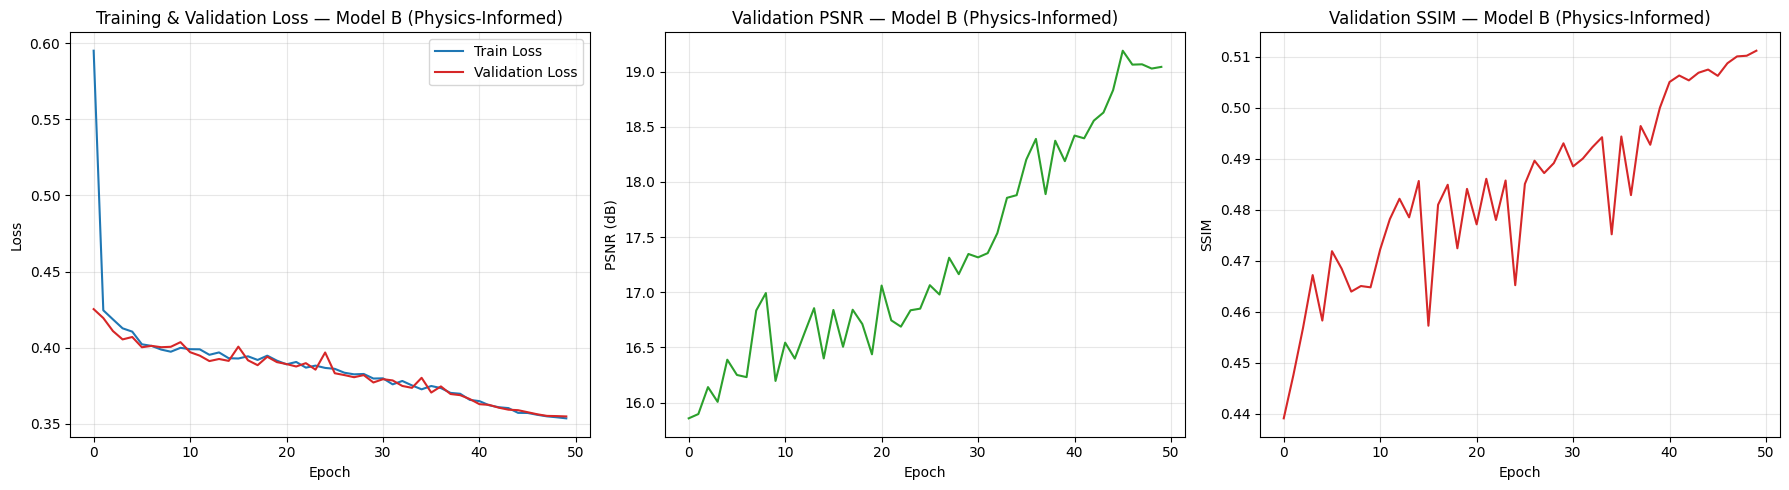

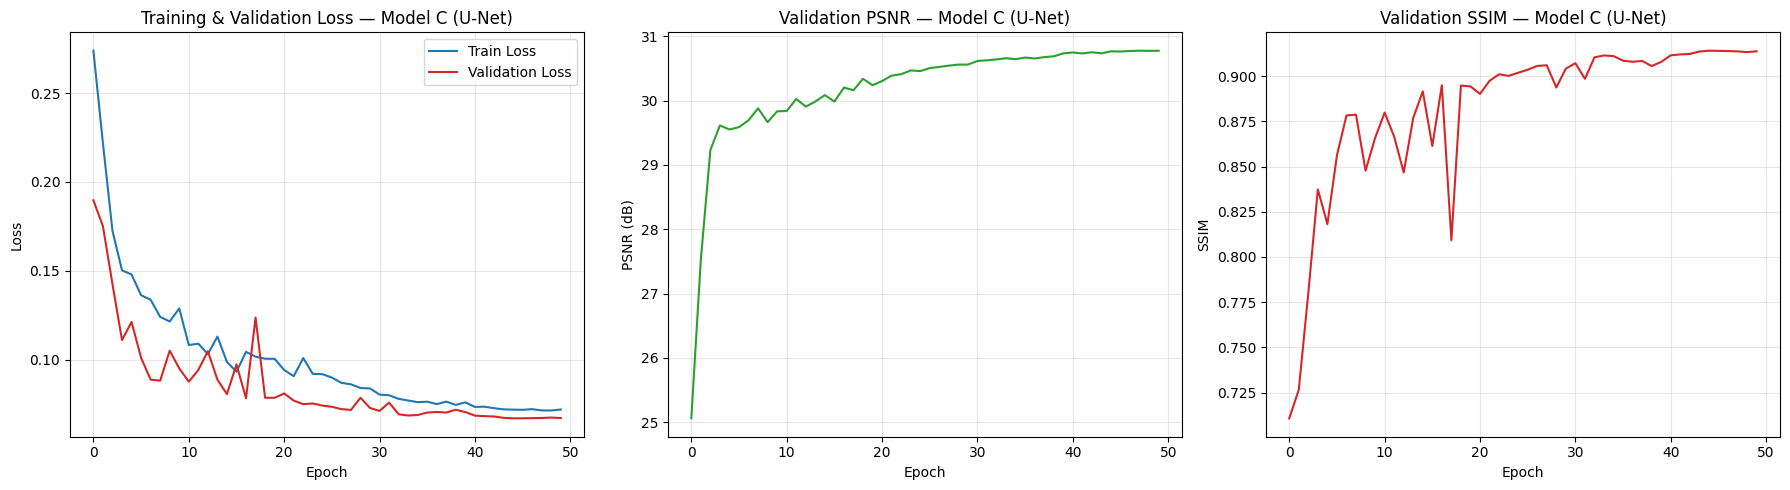

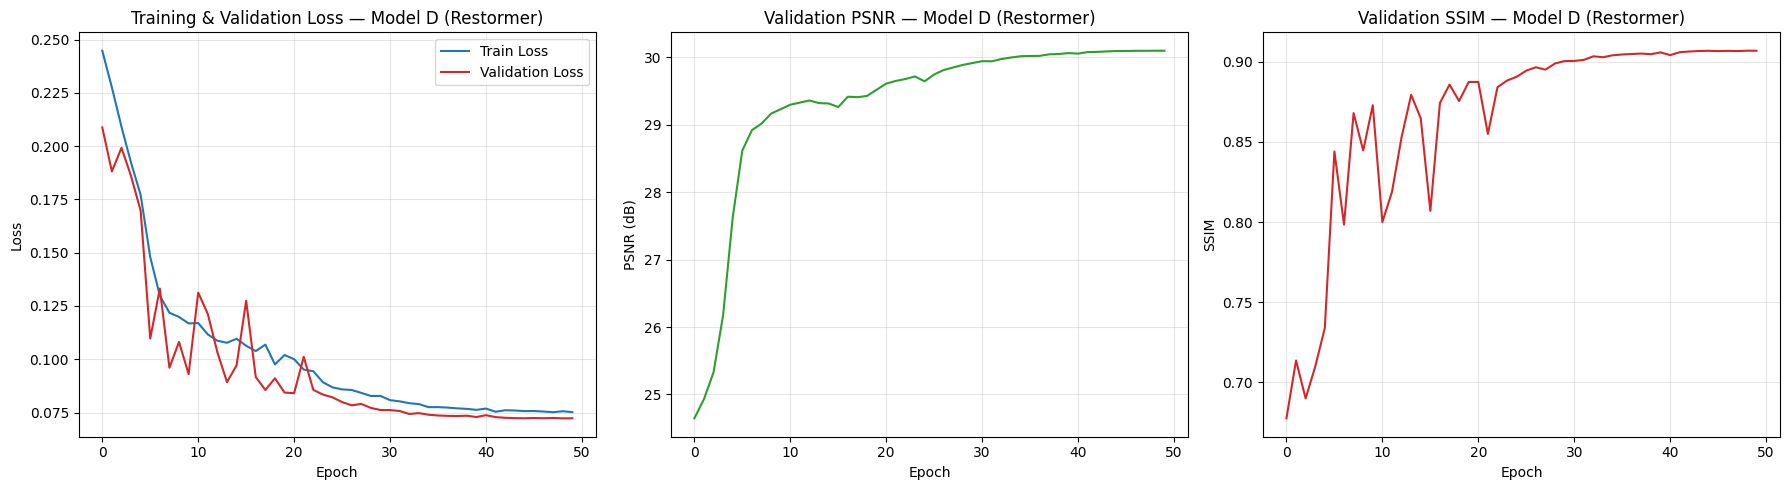

In [28]:
def plot_training_curves(history, model_label, color_train='tab:blue', color_val='tab:red'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', color=color_train)
    axes[0].plot(history['val_loss'], label='Validation Loss', color=color_val)
    axes[0].set_title(f'Training & Validation Loss — {model_label}')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['val_psnr'], color='tab:green')
    axes[1].set_title(f'Validation PSNR — {model_label}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('PSNR (dB)')
    axes[1].grid(alpha=0.3)

    axes[2].plot(history['val_ssim'], color='tab:red')
    axes[2].set_title(f'Validation SSIM — {model_label}')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('SSIM')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    fname = 'training_curves_' + model_label.lower().replace(' ', '_').replace('-', '_') + '.png'
    plt.savefig(os.path.join(CFG_BASE['checkpoint_dir'], fname), dpi=150)
    plt.show()

plot_training_curves(history_a, 'Model A (Visual Mamba)')
plot_training_curves(history_b, 'Model B (Physics-Informed)')
plot_training_curves(history_c, 'Model C (U-Net)')
plot_training_curves(history_d, 'Model D (Restormer)')

## 21. Final Comparison — Mamba vs. Physics-Informed vs. U-Net vs. Restormer

Final metrics are taken from each model's best checkpoint (highest smoothed validation PSNR epoch), re-evaluated on the same
fixed validation set used throughout training — a genuine apples-to-apples comparison across all four decoder architectures on
the same encoder.


In [34]:
def load_best_and_eval(model_name, model_dict, forward_fn, encoder_dict, cfg, fixed_batches):
    ckpt_path = os.path.join(cfg['checkpoint_dir'], model_name, 'checkpoint_best.pth')
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    load_functional_state(ckpt['model'], model_dict)
    if ckpt.get('encoder') is not None:
        load_functional_state(ckpt['encoder'], encoder_dict)
    val_loss, val_psnr, val_ssim, val_lpips = validate(model_dict, forward_fn, encoder_dict, cfg, fixed_batches)
    return {'psnr': val_psnr, 'ssim': val_ssim, 'lpips': val_lpips, 'best_epoch': ckpt['epoch']}


metrics_a = load_best_and_eval('model_a_visual_mamba', model_a_small, model_a_forward, encoder, CFG_A_SMALL, FIXED_VAL_BATCHES)
metrics_b = load_best_and_eval('model_b_physics_informed', model_b, model_b_forward, encoder_b, CFG_B, FIXED_VAL_BATCHES)
metrics_c = load_best_and_eval('model_c_unet', model_c, model_c_forward, encoder_c, CFG_C, FIXED_VAL_BATCHES)
metrics_d = load_best_and_eval('model_d_restormer', model_d, model_d_forward, encoder_d, CFG_D, FIXED_VAL_BATCHES)

rows = [
    ('US-JEPA + Visual Mamba',       metrics_a['psnr'], metrics_a['ssim'], metrics_a['lpips'], time_a, n_params_a),
    ('US-JEPA + Physics-Informed',   metrics_b['psnr'], metrics_b['ssim'], metrics_b['lpips'], time_b, n_params_b),
    ('US-JEPA + U-Net',              metrics_c['psnr'], metrics_c['ssim'], metrics_c['lpips'], time_c, n_params_c),
    ('US-JEPA + Restormer',          metrics_d['psnr'], metrics_d['ssim'], metrics_d['lpips'], time_d, n_params_d),
]

psnr_rank = sorted(rows, key=lambda r: r[1], reverse=True)
ssim_rank = sorted(rows, key=lambda r: r[2], reverse=True)
lpips_rank = sorted(rows, key=lambda r: r[3])   # lower LPIPS = better

def rank_score(name):
    return ([r[0] for r in psnr_rank].index(name)
             + [r[0] for r in ssim_rank].index(name)
             + [r[0] for r in lpips_rank].index(name))

scores = {row[0]: rank_score(row[0]) for row in rows}
best_model = min(scores, key=scores.get)

print(f'{"Model":<32}{"PSNR":>10}{"SSIM":>10}{"LPIPS":>10}{"Time (min)":>14}{"Params":>14}')
print('-' * 90)
for name, psnr, ssim_v, lpips_v, elapsed, n_params in rows:
    print(f'{name:<32}{psnr:>10.2f}{ssim_v:>10.4f}{lpips_v:>10.4f}{elapsed/60:>14.1f}{n_params:>14,}')

print(f'\nBest overall (fixed val set, rank-averaged over PSNR/SSIM/LPIPS): {best_model}')

Model                                 PSNR      SSIM     LPIPS    Time (min)        Params
------------------------------------------------------------------------------------------
US-JEPA + Visual Mamba               21.48    0.5800    0.4156          62.2     1,534,789
US-JEPA + Physics-Informed           19.04    0.5112    0.4768          25.2       572,547
US-JEPA + U-Net                      30.77    0.9137    0.0967          33.2     1,884,737
US-JEPA + Restormer                  30.10    0.9069    0.1265          68.4     1,673,627

Best overall (fixed val set, rank-averaged over PSNR/SSIM/LPIPS): US-JEPA + U-Net


In [35]:
# Rendered comparison table
from IPython.display import Markdown, display

results = {name: {'PSNR': psnr, 'SSIM': ssim_v, 'LPIPS': lpips_v, 'Params': n_params, 'Time (min)': elapsed / 60}
           for name, psnr, ssim_v, lpips_v, elapsed, n_params in rows}

higher_is_better = {'PSNR': True, 'SSIM': True, 'LPIPS': False, 'Params': False, 'Time (min)': False}
winners = {}
for metric in higher_is_better:
    better_fn = max if higher_is_better[metric] else min
    winners[metric] = better_fn(results, key=lambda k: results[k][metric])

def fmt(name, metric, is_int=False):
    val = results[name][metric]
    text = f'{val:,}' if is_int else f'{val:.4f}'
    return f'**{text} ✅**' if winners[metric] == name else text

table_lines = ['| Model | PSNR | SSIM | LPIPS | Params | Time (min) |', '|---|---|---|---|---|---|']
for name in results:
    table_lines.append(
        f"| {name} | {fmt(name, 'PSNR')} | {fmt(name, 'SSIM')} | {fmt(name, 'LPIPS')} | "
        f"{fmt(name, 'Params', is_int=True)} | {fmt(name, 'Time (min)')} |"
    )
table_lines.append('')
table_lines.append(f'**Best overall (rank-averaged): {best_model}**')

display(Markdown(chr(10).join(table_lines)))

| Model | PSNR | SSIM | LPIPS | Params | Time (min) |
|---|---|---|---|---|---|
| US-JEPA + Visual Mamba | 21.4836 | 0.5800 | 0.4156 | 1,534,789 | 62.2251 |
| US-JEPA + Physics-Informed | 19.0436 | 0.5112 | 0.4768 | **572,547 ✅** | **25.1582 ✅** |
| US-JEPA + U-Net | **30.7739 ✅** | **0.9137 ✅** | **0.0967 ✅** | 1,884,737 | 33.1887 |
| US-JEPA + Restormer | 30.0977 | 0.9069 | 0.1265 | 1,673,627 | 68.4340 |

**Best overall (rank-averaged): US-JEPA + U-Net**

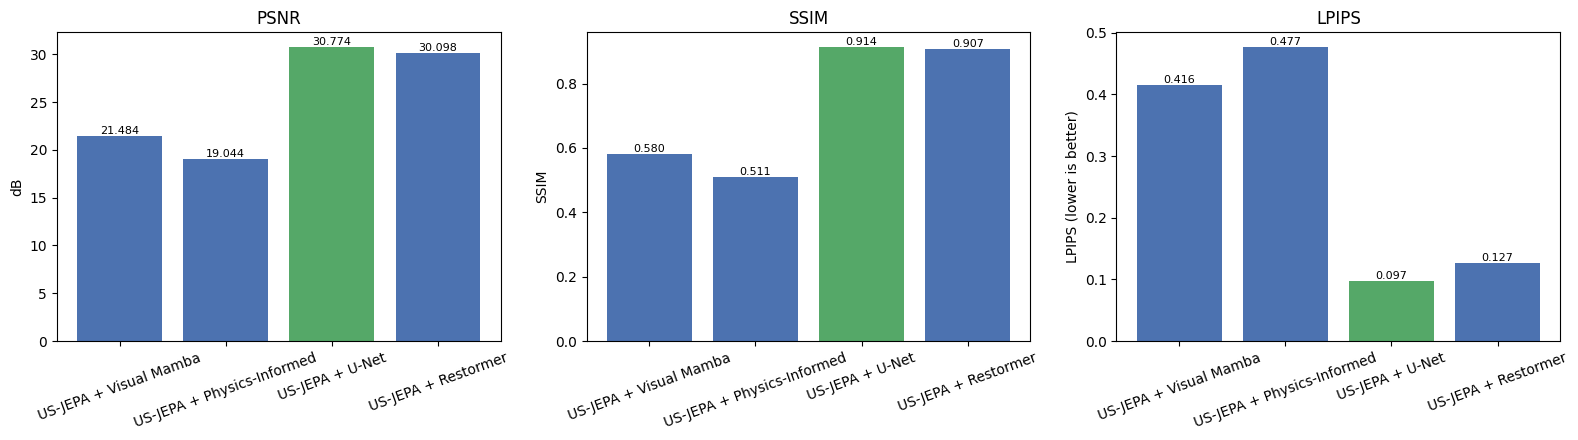

In [36]:
# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

def bar_chart(metric_name, ylabel, ax):
    names = list(results.keys())
    values = [results[n][metric_name] for n in names]
    colors = ['#55A868' if n == winners[metric_name] else '#4C72B0' for n in names]
    bars = ax.bar(names, values, color=colors)
    ax.set_title(metric_name)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bar_chart('PSNR', 'dB', axes[0])
bar_chart('SSIM', 'SSIM', axes[1])
bar_chart('LPIPS', 'LPIPS (lower is better)', axes[2])
plt.tight_layout()
plt.show()

## 22. Qualitative Comparison

Noisy input → ground truth → each model's prediction, for a handful of fixed validation examples.


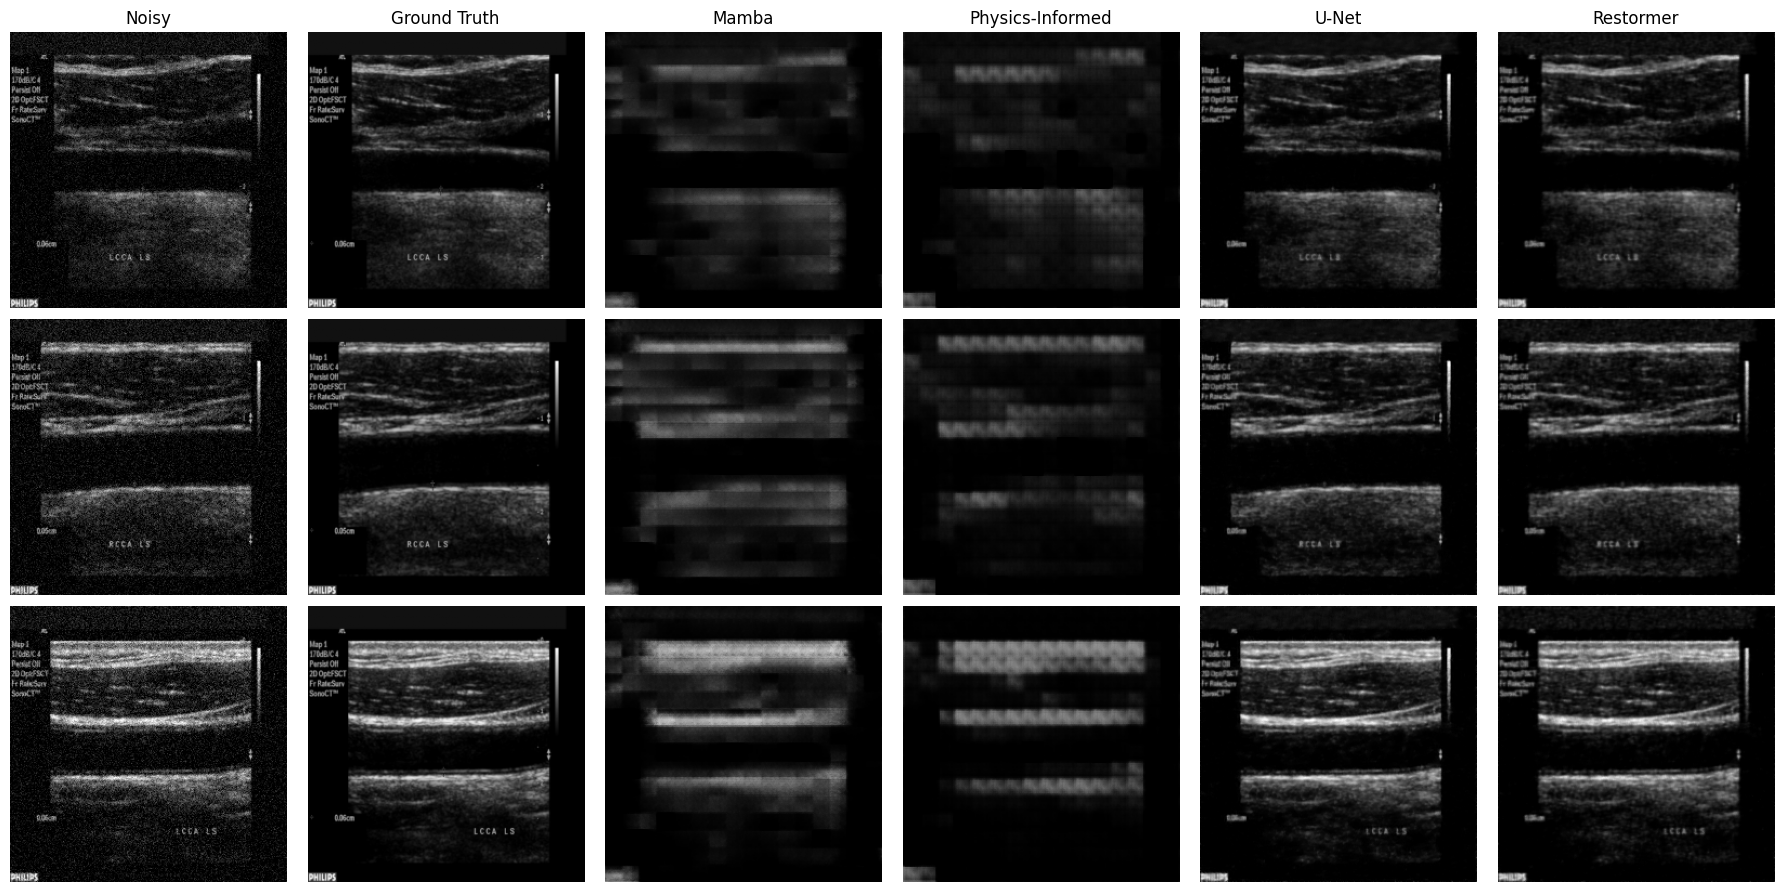

In [39]:
@torch.no_grad()
def show_predictions_all(fixed_batches, n_examples=4):
    batch = fixed_batches[0]
    noisy_all = batch['noisy'][:n_examples].to(DEVICE)
    clean_all = batch['clean'][:n_examples].to(DEVICE)

    set_module_tree_eval_or_train(model_a_small, train=False); set_module_tree_eval_or_train(encoder, train=False)
    set_module_tree_eval_or_train(model_b, train=False); set_module_tree_eval_or_train(encoder_b, train=False)
    set_module_tree_eval_or_train(model_c, train=False); set_module_tree_eval_or_train(encoder_c, train=False)
    set_module_tree_eval_or_train(model_d, train=False); set_module_tree_eval_or_train(encoder_d, train=False)

    pred_a = model_a_forward(noisy_all, encoder, model_a_small).clamp(0, 1)
    pred_b = model_b_forward(noisy_all, encoder_b, model_b).clamp(0, 1)
    pred_c = model_c_forward(noisy_all, encoder_c, model_c).clamp(0, 1)
    pred_d = model_d_forward(noisy_all, encoder_d, model_d).clamp(0, 1)

    col_titles = ['Noisy', 'Ground Truth', 'Mamba', 'Physics-Informed', 'U-Net', 'Restormer']
    fig, axes = plt.subplots(n_examples, 6, figsize=(18, 3 * n_examples))
    if n_examples == 1:
        axes = axes[None, :]
    for row in range(n_examples):
        imgs = [noisy_all[row, 0].cpu().numpy(), clean_all[row, 0].cpu().numpy(),
                pred_a[row, 0].cpu().numpy(), pred_b[row, 0].cpu().numpy(),
                pred_c[row, 0].cpu().numpy(), pred_d[row, 0].cpu().numpy()]
        for col in range(6):
            axes[row, col].imshow(imgs[col], cmap='gray', vmin=0, vmax=1)
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(col_titles[col])
    plt.tight_layout()
    plt.show()

show_predictions_all(FIXED_VAL_BATCHES, n_examples=3)

In [38]:
import shutil

# Zip all four models' checkpoints (+ config.json) into one downloadable archive
zip_path = '/kaggle/working/checkpoints_denoise_all'
shutil.make_archive(zip_path, 'zip', CFG_BASE['checkpoint_dir'])
print(f'Saved: {zip_path}.zip')

# Quick sanity check — confirm all four best checkpoints actually exist before zipping
import os
for name in ['model_a_visual_mamba', 'model_b_physics_informed', 'model_c_unet', 'model_d_restormer']:
    p = os.path.join(CFG_BASE['checkpoint_dir'], name, 'checkpoint_best.pth')
    print(name, '→', 'OK' if os.path.exists(p) else 'MISSING', p)

Saved: /kaggle/working/checkpoints_denoise_all.zip
model_a_visual_mamba → OK ./checkpoints_denoise/model_a_visual_mamba/checkpoint_best.pth
model_b_physics_informed → OK ./checkpoints_denoise/model_b_physics_informed/checkpoint_best.pth
model_c_unet → OK ./checkpoints_denoise/model_c_unet/checkpoint_best.pth
model_d_restormer → OK ./checkpoints_denoise/model_d_restormer/checkpoint_best.pth


### Notes on interpreting the comparison

- **PSNR / SSIM** favor pixel- and structure-level fidelity — the Physics-Informed decoder's speckle-gating and edge/smoothness
  loss terms are designed to help here, especially in homogeneous tissue regions.
- **LPIPS** is a rough perceptual-quality proxy (natural-image backbone, see Section 14 caveat) — treat it as directional on
  ultrasound, not definitive.
- Model A trains with pure `w_l1` loss, Model B with the full physics stack, Models C/D with `w_l1 + w_ssim` — so this table
  compares each decoder trained the way its design was intended to be used, not a loss-controlled ablation.
- If `freeze_encoder=False`, each model fine-tunes its own encoder copy independently (`encoder`, `encoder_b`, `encoder_c`,
  `encoder_d`), so differences partly reflect how each objective reshapes the shared representation, not just decoder
  architecture in isolation. Set `freeze_encoder=True` for the cleanest architecture-only comparison.
- Params-normalized caveat: the four decoders have different trainable-parameter counts (printed above and in the comparison
  table) — read any PSNR/SSIM edge alongside that capacity gap, not as attributable to the mixer/attention mechanism alone.
